# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [ ]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [ ]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

In [ ]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [ ]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


In [1]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.datasets import load_iris

# Cargamos el dataset para el ejemplo
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Aplicamos MinMax
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df), columns=df.columns)

# Comparamos
print("Original:\n", df.describe().loc[['min', 'max', 'mean']])
print("\nMinMax:\n", df_minmax.describe().loc[['min', 'max', 'mean']])

Original:
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
min            4.300000          2.000000              1.000          0.100000
max            7.900000          4.400000              6.900          2.500000
mean           5.843333          3.057333              3.758          1.199333

MinMax:
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
min            0.000000          0.000000           0.000000          0.000000
max            1.000000          1.000000           1.000000          1.000000
mean           0.428704          0.440556           0.467458          0.458056


### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

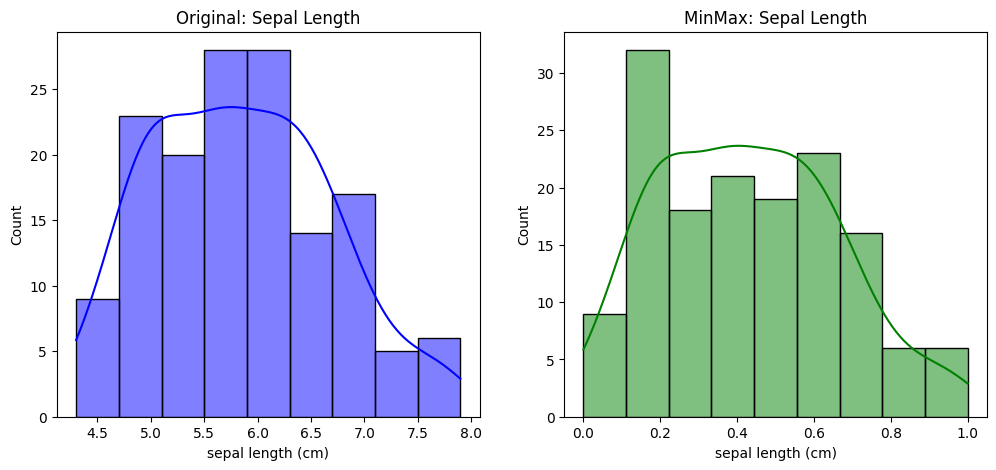

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes del escalado
sns.histplot(df['sepal length (cm)'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Original: Sepal Length')

# Después del escalado
sns.histplot(df_minmax['sepal length (cm)'], kde=True, ax=axes[1], color='green')
axes[1].set_title('MinMax: Sepal Length')

plt.show()

### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

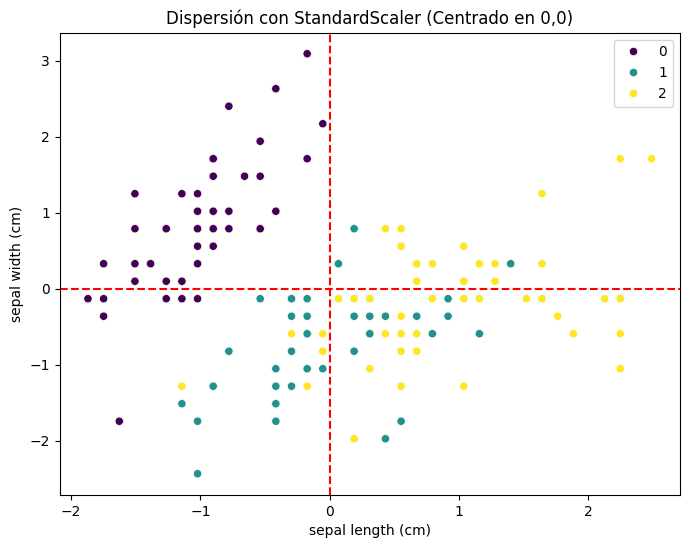

In [3]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
df_std = pd.DataFrame(scaler_std.fit_transform(df), columns=df.columns)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_std, x='sepal length (cm)', y='sepal width (cm)', hue=iris.target, palette='viridis')
plt.axhline(0, color='red', linestyle='--') # Línea en el origen
plt.axvline(0, color='red', linestyle='--')
plt.title('Dispersión con StandardScaler (Centrado en 0,0)')
plt.show()

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

In [ ]:
Considero que el StandardScaler es la técnica más adecuada para este conjunto de datos por las siguientes razones:

Robustez frente a valores atípicos (Outliers): A diferencia del MinMaxScaler, que es extremadamente sensible a valores extremos (ya que un solo dato muy alto puede "comprimir" a todos los demás en un rango muy pequeño cerca del cero), el StandardScaler utiliza la media y la desviación estándar. Esto permite que los datos mantengan su distribución original y que los valores atípicos no distorsionen la escala de todo el dataset.

Preparación para algoritmos de ML: Muchos algoritmos de aprendizaje supervisado y no supervisado (como SVM, K-Means o Regresión Logística) asumen que los datos están centrados en cero y tienen una varianza uniforme. El escalado estándar facilita la convergencia de estos modelos.